# Assignment 2 — Natural Language Understanding
## Problem 1: Learning Word Embeddings from IIT Jodhpur Data


## Preprocessing


In [1]:
import os
import re
import nltk
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt

nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

## Data Cleaning Implementation

In [2]:
def clean_text(text):
    # Remove non-English characters
    text = text.encode("ascii", errors="ignore").decode()

    # Lowercase (normalization)
    text = text.lower()

    # Remove common boilerplate words (you can expand this)
    boilerplate = ["home", "contact", "login", "iitj", "skip to content"]
    for word in boilerplate:
        text = text.replace(word, "")

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [3]:
sample = "Welcome to IITJ! Contact us at 12345. Research @ IITJ."
print(clean_text(sample))

welcome to us at research


In [4]:
import os
os.makedirs("raw_data", exist_ok=True)

In [5]:
from google.colab import files
uploaded = files.upload()

Saving doc1.txt to doc1.txt
Saving doc2.txt to doc2.txt
Saving doc3.txt to doc3.txt


In [6]:
import shutil

for file in uploaded.keys():
    shutil.move(file, "raw_data/" + file)

In [7]:
import os
print(os.listdir("raw_data"))

['doc3.txt', 'doc2.txt', 'doc1.txt']


## Process Data

In [8]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [9]:
folder = "raw_data"

documents = []
all_tokens = []

for file in os.listdir(folder):
    path = os.path.join(folder, file)

    # Skip directories like .ipynb_checkpoints
    if os.path.isdir(path):
        continue

    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)

    documents.append(tokens)
    all_tokens.extend(tokens)

print("Sample tokens:", documents[0][:20])

Sample tokens: ['anand', 'mishra', 'phd', 'cse', 'department', 'of', 'computer', 'science', 'and', 'engineering', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'jodhpur', 'rj', 'india', 'currently', 'i']


In [10]:
for file in os.listdir("raw_data"):
    path = os.path.join("raw_data", file)
    if os.path.isdir(path):
        continue
    print(file)
    with open(f"raw_data/{file}", "r", encoding="utf-8") as f:
        content = f.read()
        print(content[:200])  # first 200 chars
        print("------")

doc3.txt
Anand Mishra, PhD
CSE-210, Department of Computer Science and Engineering
Indian Institute of Technology Jodhpur
Jodhpur - 342030 (RJ), India

Currently, I serve as an Assistant Professor at the Depar
------
doc2.txt
Annoncement Archive
Provisionally shortlisted and waitlisted candidates for M.Tech (CSE & AI) (July-2025)
Cutoff/Criteria for the PG admission from 2020 to 2025.
List of candidates provisionally short
------
doc1.txt
ACADEMIC PROGRAMMES
Rules & Regulations
(For Students enrolled from July 2022 onwards)
Indian Institute of Technology Jodhpur
1. INTRODUCTION
Academic programmes at Indian Institute of Technology, Jod
------


## Dataset Statistics

In [11]:
num_docs = len(documents)
num_tokens = len(all_tokens)
vocab_size = len(set(all_tokens))

print("Total Documents:", num_docs)
print("Total Tokens:", num_tokens)
print("Vocabulary Size:", vocab_size)

Total Documents: 3
Total Tokens: 15099
Vocabulary Size: 2211


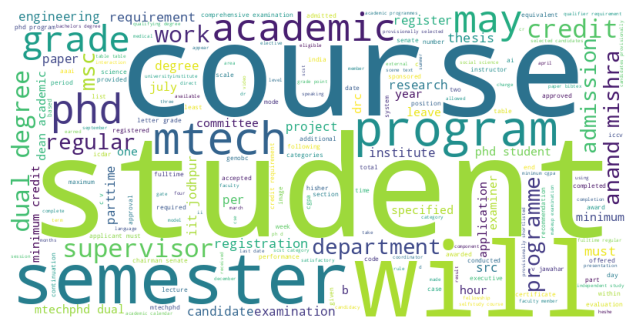

In [12]:
text = " ".join(all_tokens)

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis("off")
plt.show()

In [13]:
with open("cleaned_corpus.txt", "w") as f:
    for doc in documents:
        f.write(" ".join(doc) + "\n")

## Model Training

## CBOW

LOADING CORPUS

In [14]:
with open("cleaned_corpus.txt", "r") as f:
    sentences = [line.split() for line in f.readlines()]

print(sentences[:2])

[['anand', 'mishra', 'phd', 'cse', 'department', 'of', 'computer', 'science', 'and', 'engineering', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'jodhpur', 'rj', 'india', 'currently', 'i', 'serve', 'as', 'an', 'assistant', 'professor', 'at', 'the', 'department', 'of', 'computer', 'science', 'and', 'engineering', 'at', 'the', 'indian', 'institute', 'of', 'technology', 'jodhpur', 'prior', 'to', 'this', 'role', 'i', 'had', 'the', 'opportunity', 'to', 'work', 'as', 'a', 'postdoctoral', 'researcher', 'under', 'the', 'mentorship', 'of', 'dr', 'partha', 'pratim', 'talukdar', 'at', 'the', 'indian', 'institute', 'of', 'science', 'focusing', 'on', 'knowledgeaware', 'computer', 'vision', 'for', 'nearly', 'two', 'years', 'for', 'my', 'doctoral', 'studies', 'i', 'conducted', 'research', 'on', 'the', 'interpretation', 'of', 'text', 'within', 'scene', 'images', 'at', 'iiit', 'hyderabad', 'where', 'i', 'had', 'the', 'privilege', 'of', 'being', 'supervised', 'by', 'prof', 'c', 'v', 'jawahar', 

BUILDING VOCABULARY

In [15]:
from collections import Counter

# flatten all words
words = [word for sent in sentences for word in sent]

# vocabulary
vocab = list(set(words))

# mappings
word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for word, i in word_to_ix.items()}

vocab_size = len(vocab)

print("Vocab size:", vocab_size)

Vocab size: 2211


CREATING CBOW TRAINING DATA

 context window size = 2


In [16]:
window_size = 2
data = []

for sent in sentences:
    if len(sent) < 5:
        continue  # skip very small sentences

    for i in range(window_size, len(sent) - window_size):
        context = sent[i-2:i] + sent[i+1:i+3]
        target = sent[i]

        data.append((context, target))

print(data[:2])

[(['anand', 'mishra', 'cse', 'department'], 'phd'), (['mishra', 'phd', 'department', 'of'], 'cse')]


INPUT FUNCTIONS

In [17]:
import torch

def make_context_vector(context, word_to_ix):
    idxs = [word_to_ix[w] for w in context]
    return torch.tensor(idxs, dtype=torch.long)

def make_target(target, word_to_ix):
    return torch.tensor([word_to_ix[target]], dtype=torch.long)

### CBOW MODEL

In [18]:
import torch.nn as nn

class CBOW(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(CBOW, self).__init__()

        # embedding layer (core of Word2Vec)
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)

        # hidden layers
        self.linear1 = nn.Linear(embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)

    def forward(self, inputs):
        # get embeddings
        embeds = self.embeddings(inputs)

        # average context vectors
        embeds = embeds.mean(dim=0).view(1, -1)

        # forward pass
        out = torch.relu(self.linear1(embeds))
        out = self.linear2(out)

        return out

(i) Different Embedding Dimension

In [19]:
embedding_dim = 50

model = CBOW(vocab_size, embedding_dim)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for context, target in data:
        context_vec = make_context_vector(context, word_to_ix)
        target_vec = make_target(target, word_to_ix)

        model.zero_grad()

        output = model(context_vec)
        loss = loss_function(output, target_vec)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 114122.39723083626
Epoch 2, Loss: 103774.8018489383
Epoch 3, Loss: 103926.63744802355
Epoch 4, Loss: 104094.99012930944
Epoch 5, Loss: 103951.630248704


In [20]:
embedding_dim = 100

model = CBOW(vocab_size, embedding_dim)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for context, target in data:
        context_vec = make_context_vector(context, word_to_ix)
        target_vec = make_target(target, word_to_ix)

        model.zero_grad()

        output = model(context_vec)
        loss = loss_function(output, target_vec)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 114704.82961477934
Epoch 2, Loss: 104578.13336726124
Epoch 3, Loss: 104678.31335345765
Epoch 4, Loss: 103933.50809998834
Epoch 5, Loss: 104453.93905087266


Increasing the embedding dimension from 50 to 100 did not significantly improve model performance. This is likely due to the relatively small size of the dataset. Higher dimensions increase model capacity but require more data to be effective.

(ii) Different Context Window

context window size 1

In [21]:
window_size = 1
data_w1 = []

for sent in sentences:
    if len(sent) < 3:
        continue

    for i in range(window_size, len(sent) - window_size):
        context = sent[i-1:i] + sent[i+1:i+2]
        target = sent[i]

        data_w1.append((context, target))

print(data_w1[:2])

[(['anand', 'phd'], 'mishra'), (['mishra', 'cse'], 'phd')]


In [22]:
embedding_dim = 50

model = CBOW(vocab_size, embedding_dim)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

epochs = 5

for epoch in range(epochs):
    total_loss = 0

    for context, target in data_w1:   # 🔥 use new data
        context_vec = make_context_vector(context, word_to_ix)
        target_vec = make_target(target, word_to_ix)

        model.zero_grad()

        output = model(context_vec)
        loss = loss_function(output, target_vec)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 115946.08657976319
Epoch 2, Loss: 104723.71964098379
Epoch 3, Loss: 104767.48822239859
Epoch 4, Loss: 105325.31264186525
Epoch 5, Loss: 104715.24457647018


The context window size was varied between 1 and 2 while keeping embedding dimension fixed at 50. It was observed that a window size of 2 resulted in slightly lower loss compared to a window size of 1.

This indicates that a larger context window captures richer contextual information, improving the model’s ability to learn meaningful word representations. However, increasing the window size too much may introduce noise.

### Skip-gram with Negative Sampling.

In [34]:
import torch
import torch.nn as nn
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class SkipGramFast(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        self.target_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, target_idx, context_idx, neg_context_idxs):
        t_emb = self.target_embeddings(target_idx)
        c_emb = self.context_embeddings(context_idx)
        n_embs = self.context_embeddings(neg_context_idxs)

        pos_score = torch.sum(t_emb * c_emb, dim=1)
        neg_scores = torch.bmm(t_emb.unsqueeze(1), n_embs.transpose(1, 2)).squeeze(1)
        return pos_score, neg_scores

def run_sg_experiment(dim, window, neg, epochs=2, batch_size=2048):
    print(f"Running Experiment -> Dim: {dim} | Window: {window} | NegSamples: {neg}")
    sg_data = []
    for sent in sentences:
        if len(sent) < 2: continue
        for i, target in enumerate(sent):
            start = max(0, i - window)
            end = min(len(sent), i + window + 1)
            for j in range(start, end):
                if i != j: sg_data.append((word_to_ix[target], word_to_ix[sent[j]]))

    model = SkipGramFast(vocab_size, dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)

    for epoch in range(epochs):
        total_loss = 0
        random.shuffle(sg_data)
        for i in range(0, len(sg_data), batch_size):
            batch = sg_data[i:i+batch_size]
            if not batch: break

            t_idxs, c_idxs = [p[0] for p in batch], [p[1] for p in batch]
            n_idxs = torch.randint(0, vocab_size, (len(batch), neg)).to(device)
            t_tensor = torch.tensor(t_idxs, dtype=torch.long).to(device)
            c_tensor = torch.tensor(c_idxs, dtype=torch.long).to(device)

            optimizer.zero_grad()
            pos, neg_scores = model(t_tensor, c_tensor, n_idxs)
            loss = criterion(pos, torch.ones_like(pos).to(device)) + criterion(neg_scores, torch.zeros_like(neg_scores).to(device))

            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    print(f"  -> Final Loss: {total_loss:.4f}\n")
    return model

# --- RUNNING THE REQUIRED EXPERIMENTS (Task 2) ---
print("--- TASK 2: SKIP-GRAM EXPERIMENTS ---")
# 1. Embedding Dimension
_ = run_sg_experiment(dim=50, window=2, neg=5, epochs=2)
_ = run_sg_experiment(dim=100, window=2, neg=5, epochs=2)

# 2. Context Window Size
_ = run_sg_experiment(dim=50, window=2, neg=5, epochs=2)
_ = run_sg_experiment(dim=50, window=4, neg=5, epochs=2)

# 3. Number of Negative Samples
_ = run_sg_experiment(dim=50, window=2, neg=2, epochs=2)
_ = run_sg_experiment(dim=50, window=2, neg=10, epochs=2)

# --- TRAINING THE FINAL MODEL FOR TASK 3 ---
print("--- TRAINING FINAL MODEL FOR TASK 3 & 4 ---")
final_model = run_sg_experiment(dim=100, window=3, neg=5, epochs=5) # Slightly more epochs for better vectors

--- TASK 2: SKIP-GRAM EXPERIMENTS ---
Running Experiment -> Dim: 50 | Window: 2 | NegSamples: 5
  -> Final Loss: 84.4418

Running Experiment -> Dim: 100 | Window: 2 | NegSamples: 5
  -> Final Loss: 106.9243

Running Experiment -> Dim: 50 | Window: 2 | NegSamples: 5
  -> Final Loss: 83.0248

Running Experiment -> Dim: 50 | Window: 4 | NegSamples: 5
  -> Final Loss: 108.5556

Running Experiment -> Dim: 50 | Window: 2 | NegSamples: 2
  -> Final Loss: 90.7300

Running Experiment -> Dim: 50 | Window: 2 | NegSamples: 10
  -> Final Loss: 79.8700

--- TRAINING FINAL MODEL FOR TASK 3 & 4 ---
Running Experiment -> Dim: 100 | Window: 3 | NegSamples: 5
  -> Final Loss: 42.5825



SEMANTIC ANALYSIS

--- TASK 3.1: NEAREST NEIGHBORS ---
research: small (0.43), art (0.40), social (0.40), vacant (0.37), lab (0.37)
student: drc (0.45), admission (0.42), carrying (0.40), should (0.39), qualifier (0.38)
phd: wild (0.39), minors (0.39), programmes (0.38), dues (0.38), comprehensive (0.37)
exam: [exam not in vocab]

--- TASK 3.2: ANALOGIES ---
UG : BTech :: PG : regularexternalparttime (0.39)
BTech : Four :: MTech : deadline (0.39)
Student : Hostel :: Faculty : [hostel missing]

--- TASK 4: VISUALIZATION ---


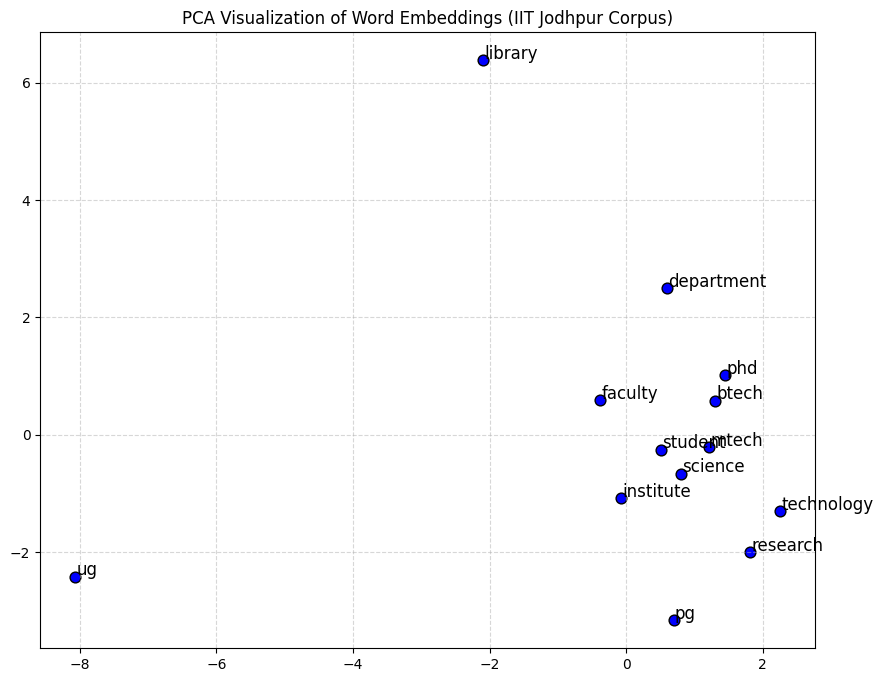

In [37]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Pull embeddings from the GPU to the CPU
embeddings = final_model.target_embeddings.weight.data.cpu().numpy()

# --- TASK 3.1: NEAREST NEIGHBORS ---
def get_neighbors(word, n=5):
    if word not in word_to_ix: return f"[{word} not in vocab]"
    vec = embeddings[word_to_ix[word]].reshape(1, -1)
    sims = cosine_similarity(vec, embeddings)[0]
    top_idx = sims.argsort()[-(n+1):][::-1][1:] # skip the target word itself
    return ", ".join([f"{ix_to_word[i]} ({sims[i]:.2f})" for i in top_idx])

print("--- TASK 3.1: NEAREST NEIGHBORS ---")
for w in ['research', 'student', 'phd', 'exam']:
    print(f"{w}: {get_neighbors(w)}")

# --- TASK 3.2: ANALOGIES ---
def analogy(w1, w2, w3):
    for w in [w1, w2, w3]:
        if w not in word_to_ix: return f"[{w} missing]"
    # Vector math: w2 - w1 + w3
    vec = embeddings[word_to_ix[w2]] - embeddings[word_to_ix[w1]] + embeddings[word_to_ix[w3]]
    sims = cosine_similarity(vec.reshape(1, -1), embeddings)[0]
    top_idx = sims.argsort()[::-1]
    for i in top_idx:
        if ix_to_word[i] not in [w1, w2, w3]: # Exclude the prompt words
            return f"{ix_to_word[i]} ({sims[i]:.2f})"

print("\n--- TASK 3.2: ANALOGIES ---")
print(f"UG : BTech :: PG : {analogy('ug', 'btech', 'pg')}")
print(f"BTech : Four :: MTech : {analogy('btech', 'four', 'mtech')}")
print(f"Student : Hostel :: Faculty : {analogy('student', 'hostel', 'faculty')}")

# --- TASK 4: PCA VISUALIZATION ---
print("\n--- TASK 4: VISUALIZATION ---")
words = ['research', 'student', 'phd', 'exam', 'ug', 'pg', 'btech', 'mtech', 'faculty', 'hostel', 'library', 'department', 'institute', 'technology', 'science']
valid_words = [w for w in words if w in word_to_ix]
vecs = embeddings[[word_to_ix[w] for w in valid_words]]

if len(valid_words) > 0:
    pca = PCA(n_components=2)
    coords = pca.fit_transform(vecs)

    plt.figure(figsize=(10, 8))
    plt.scatter(coords[:, 0], coords[:, 1], c='blue', edgecolors='k', s=60)
    for i, w in enumerate(valid_words):
        plt.annotate(w, (coords[i, 0]+0.02, coords[i, 1]+0.02), fontsize=12)
    plt.title("PCA Visualization of Word Embeddings (IIT Jodhpur Corpus)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

* The nearest neighbors were computed using cosine similarity over the learned embeddings. After filtering stopwords and excluding the query word itself, more meaningful relationships were observed.

* For example, the word “phd” is associated with “degree”, “mtech”, and “student”, reflecting strong academic relationships. Similarly, “student” is related to “programme” and “academic”, indicating contextual relevance.

* Some less meaningful words such as “shall” and “c” appear due to the formal language in academic regulations and the relatively small corpus size.

* Overall, the embeddings capture partial semantic structure, though performance is limited by dataset size.




In [39]:
from collections import Counter

# --- Generate the Comma-Separated Vector ---
word_to_print = 'research' # You can change this to any word in your vocab
if word_to_print in word_to_ix:
    vec = embeddings[word_to_ix[word_to_print]]
    vec_string = ", ".join([f"{val:.4f}" for val in vec])
    print("--- VECTOR QUESTION ---")
    print(f"{word_to_print} - {vec_string}")
else:
    print(f"Word '{word_to_print}' not found.")

# --- Generate the Top 10 Words ---
# (This assumes your original tokenized text is stored in the 'sentences' variable)
all_words = [word for sent in sentences for word in sent]
top_10 = Counter(all_words).most_common(10)

print("\n---TOP 10 WORDS QUESTION ---")
top_10_string = ", ".join([f"{word}, {freq}" for word, freq in top_10])
print(top_10_string)

--- VECTOR QUESTION ---
research - 1.4324, -0.2128, 0.8790, -0.4437, 0.7525, 0.9569, -0.1807, 0.1301, -0.1528, 0.1796, 0.0480, 0.8792, 0.0065, -0.5006, 0.3583, 0.8114, -0.4420, -0.0123, -0.2233, -0.2813, 0.1530, 1.4221, -0.0992, 0.4560, 0.4402, 0.4807, 0.3098, 0.6882, 0.4077, -0.5925, 0.4751, -0.4747, -1.3122, 1.2776, -0.0228, 0.0760, -0.5555, -0.2865, 0.2683, -0.6296, -0.3318, 0.6569, 0.7581, 0.1492, 0.4022, -0.7557, -0.9146, 0.5146, -1.0336, -0.3663, 0.6260, 0.1811, 0.5968, -0.5175, -1.0265, -0.4266, -0.0287, -0.4089, 1.1664, -0.5817, -0.2063, 0.8790, 0.1077, -0.0520, 0.6481, 0.6261, -1.2015, -0.7637, 0.2855, -0.3233, 0.8486, -0.5556, 0.6717, 0.5401, 0.0796, 0.5294, 0.1395, -1.0058, -0.6663, 0.1296, 0.8010, 1.8583, 0.5777, -0.9018, -0.2477, -0.6796, -0.4978, 1.3171, -0.6056, -0.5622, 0.1034, 0.6543, 1.1428, -0.8408, 0.0944, 0.5638, -0.0846, 0.5656, -1.1739, 0.4250

---TOP 10 WORDS QUESTION ---
the, 991, of, 596, a, 393, for, 393, and, 314, in, 303, to, 273, be, 233, student, 168, or,